In [1]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt 
import numpy.ma as ma

import torch
import torch.nn as nn
import torch.optim as optim

import scipy
from scipy.spatial import cKDTree

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
import ot
import time

import imageio
import os
from IPython.display import Image, HTML

dict_keys(['lat', 'lon', 'sst', 'time'])


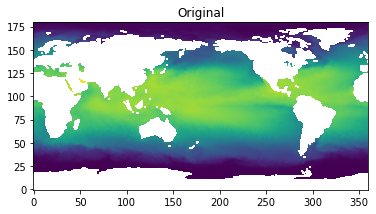

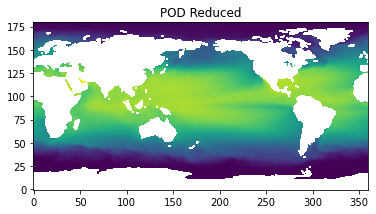

In [2]:
############# Import dataset and split into train/test sets
############# The following dataset can be downloaded from "https://psl.noaa.gov/thredds/catalog/Datasets/noaa.oisst.v2/new/catalog.html"
dataset = nc.Dataset('sst.oisst.mon.mean.1982.nc')
print(dataset.variables.keys())
sst = dataset.variables['sst'][:]
mask = sst.mask[0]
values = sst.data
states =[]
for i in range(len(values)):
    states.append(values[i][~mask])
states = np.array(states)

states_train = states[:300]
states_test = states[300:]
######################


############### Form POD for dimension reduction of full state which has dimension ~45,000.
Nmodes = 4 #number of POD modes (this is the state dimension we perform estimation in)

def Snap_POD(DATA,Nmodes):
    S = DATA.T
    Sbar = np.mean(S,axis = 1).reshape(len(S),1)
    X = S - Sbar
    C = X.T.dot(X)
    Lambda,W = np.linalg.eig(C)
    idx = np.argsort(Lambda)[::-1]
    W = W[:,idx]
    Lambda = Lambda[idx]
    W = W[:,:Nmodes]
    Lambdapow = Lambda[:Nmodes]**(-1/2)
    Lambdapow = np.diag(Lambdapow)
    modes = (X.dot(W)).dot(Lambdapow)
    coeffs = modes.T.dot(X)
    return modes, coeffs.T, Sbar

def Reconstruct_POD(modes,coeffs, mean):
    return (modes.dot(coeffs.T) +  mean).T

def Remap(reconstructed):
    full = np.zeros((len(reconstructed),180,360))
    ixs = np.where(mask == False)
    for i in range(len(reconstructed)):
            full[i][ixs[0],ixs[1]] = reconstructed[i]
    return ma.array(full,mask = sst.mask[:len(reconstructed)])
    
modes, coeffs, mean = Snap_POD(states_train,Nmodes) #we will apply our learning algorithm to "coeffs." No need to touch "modes" or "mean". Note that we still will need to rescale the features of coeffs to feed it into a neural network 
reconstructed = Reconstruct_POD(modes,coeffs,mean) #this is how you reconstruct the full state based on coeffs 
remapped = Remap(reconstructed) #this is how you map back to the "world-map" view for plotting purposes

plt.title('Original')
plt.imshow(sst[235],origin = 'lower')
plt.show()
plt.title('POD Reduced')
plt.imshow(remapped[235],origin = 'lower') 

# The goal is to train a model for "coeffs" and then to predict the evolution of coeffs into the testing phase. THen use the reconstruct_POD function to reconstruct the full state for the testing phase and compare to the ground truth. 



In [3]:


relu = nn.ReLU()

def decay(x):
    return relu(1-slope*x)
def w(xs):
    dists =  torch.cdist(xs, Voronoi_centers, p =2)
    pre_w = decay(dists)
    return  pre_w / torch.sum(pre_w, dim=1,keepdim = True)

def Ulam(points,Tpoints):
    mat = torch.zeros((subset_size, subset_size))
    #before normalization
    with torch.no_grad():
          randpts_idxs = torch.tensor(tree.query(points.detach().numpy())[1], dtype=torch.int)
    weights = w(Tpoints)
    mat.index_add_(0, randpts_idxs, weights)
    #mat = mat[nonempty_cells][:, nonempty_cells]
    row_sums = mat.sum(dim=1)
    normalized_mat = torch.where(row_sums == 0, mat, (mat.T / row_sums))
    return normalized_mat


In [4]:
noise_level = 0.5
trajectory = coeffs + np.random.normal(0,noise_level,((300,4)))

In [5]:
subset_size = 40

slope = 0.002
steps = 1
dt = 1e-2
sample_size = 250
scaler = StandardScaler()
scaled_coeffs = scaler.fit_transform(trajectory)

# Select training points
randpts = scaled_coeffs[:sample_size]
Trandpts = scaled_coeffs[1:sample_size+1]

# Convert to torch tensors
randpts = torch.tensor(randpts, dtype=torch.float32)
Trandpts = torch.tensor(Trandpts, dtype=torch.float32)

In [6]:

Voronoi_centers = MiniBatchKMeans(n_clusters=subset_size).fit(randpts).cluster_centers_
tree = cKDTree(Voronoi_centers)
Voronoi_centers = torch.tensor(Voronoi_centers,dtype = torch.float)
U_true = Ulam(randpts,Trandpts)
U_true_np = U_true.detach().cpu().numpy()
class W2Loss(torch.autograd.Function):#MAT
    @staticmethod
    def forward(ctx, U_net):
        U_net_np = U_net.detach().numpy()
        cost_cols,grad = np.zeros(subset_size),np.zeros((subset_size,subset_size))
        costM = ot.dist(np.arange(subset_size).reshape(-1, 1), np.arange(subset_size).reshape(-1, 1))
        for col in range(subset_size):
            _, log = ot.emd(U_true_np[:,col], U_net_np[:,col], costM, log=True)
            cost_cols[col],grad[col] = log['cost'],log["v"]
        loss,grad = np.sum(cost_cols),grad.T
        grad_tensor = torch.tensor(grad, dtype=U_net.dtype)
        ctx.save_for_backward(grad_tensor)
        return torch.tensor(loss, dtype=U_net.dtype)
    @staticmethod
    def backward(ctx, grad_output):
        grad_tensor, = ctx.saved_tensors  # Unpack gradient
        return grad_tensor.reshape(subset_size,subset_size)


/homes/yinonghyn/.local/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1930: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


In [7]:
torch.manual_seed(100000)
net1 = nn.Sequential(
            nn.Linear(4, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 4))

optimizer1 = optim.Adam(net1.parameters(),lr = 1e-3)
scheduler1 = optim.lr_scheduler.StepLR(optimizer1, step_size=2000, gamma=0.5) 
net1.train()
loss1 = []
N_iters = 20000
net1_randpts = randpts.clone()  # safe copy, avoid modifying original tensor

V_field = net1(net1_randpts)
net1_randpts = net1_randpts + dt * V_field  # out-of-place update
U_net = Ulam(randpts, net1_randpts)
initial_L1 = W2Loss.apply(U_net)

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


Iteration 0, Loss(Ulam): 0.059346169233322144


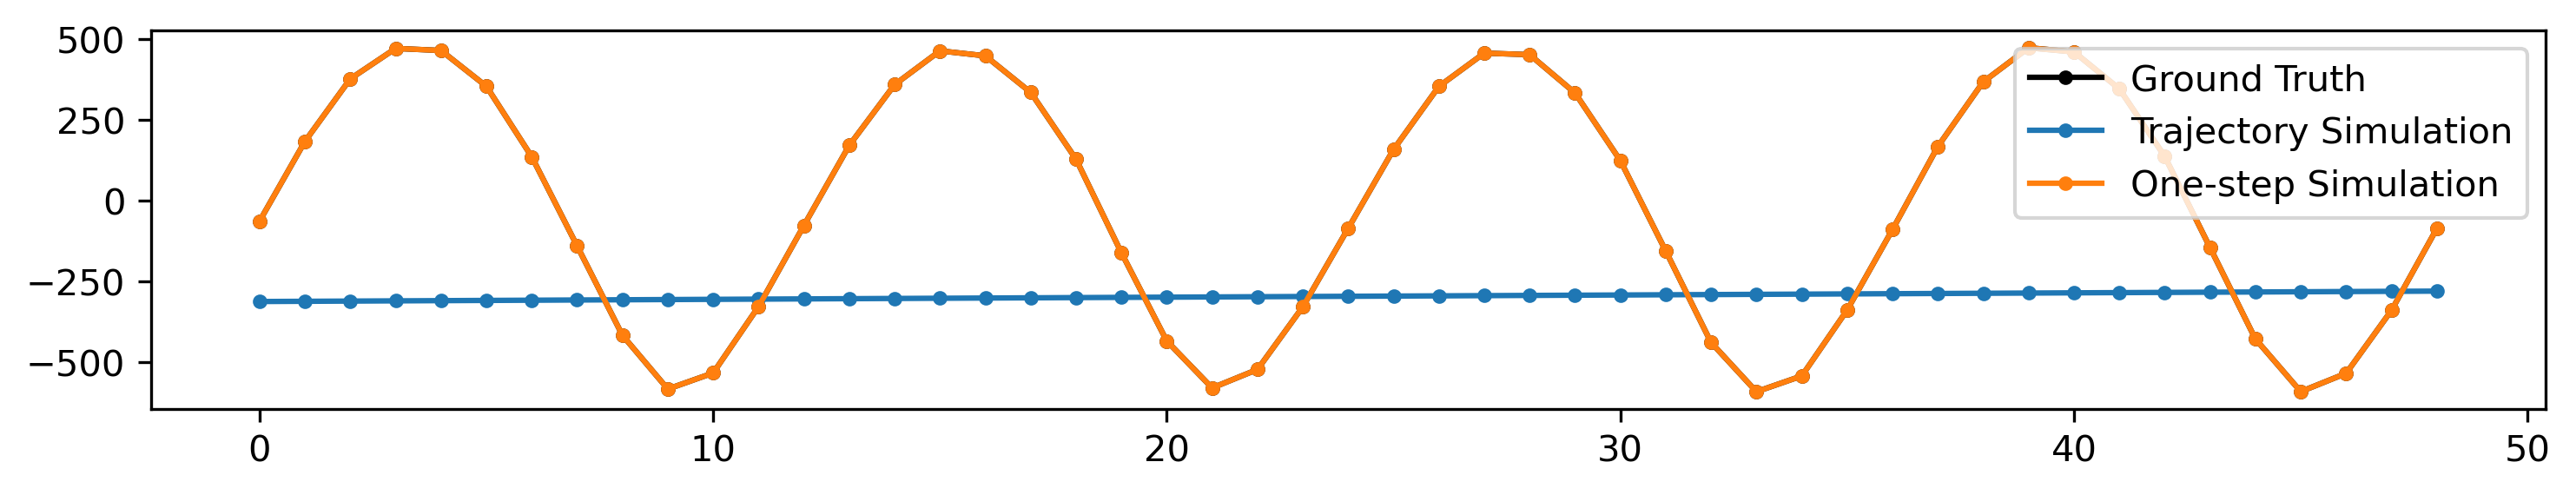

Iteration 500, Loss(Ulam): 0.03771842643618584
Iteration 1000, Loss(Ulam): 0.025978583842515945
Iteration 1500, Loss(Ulam): 0.014019085094332695
Iteration 2000, Loss(Ulam): 0.0073255207389593124


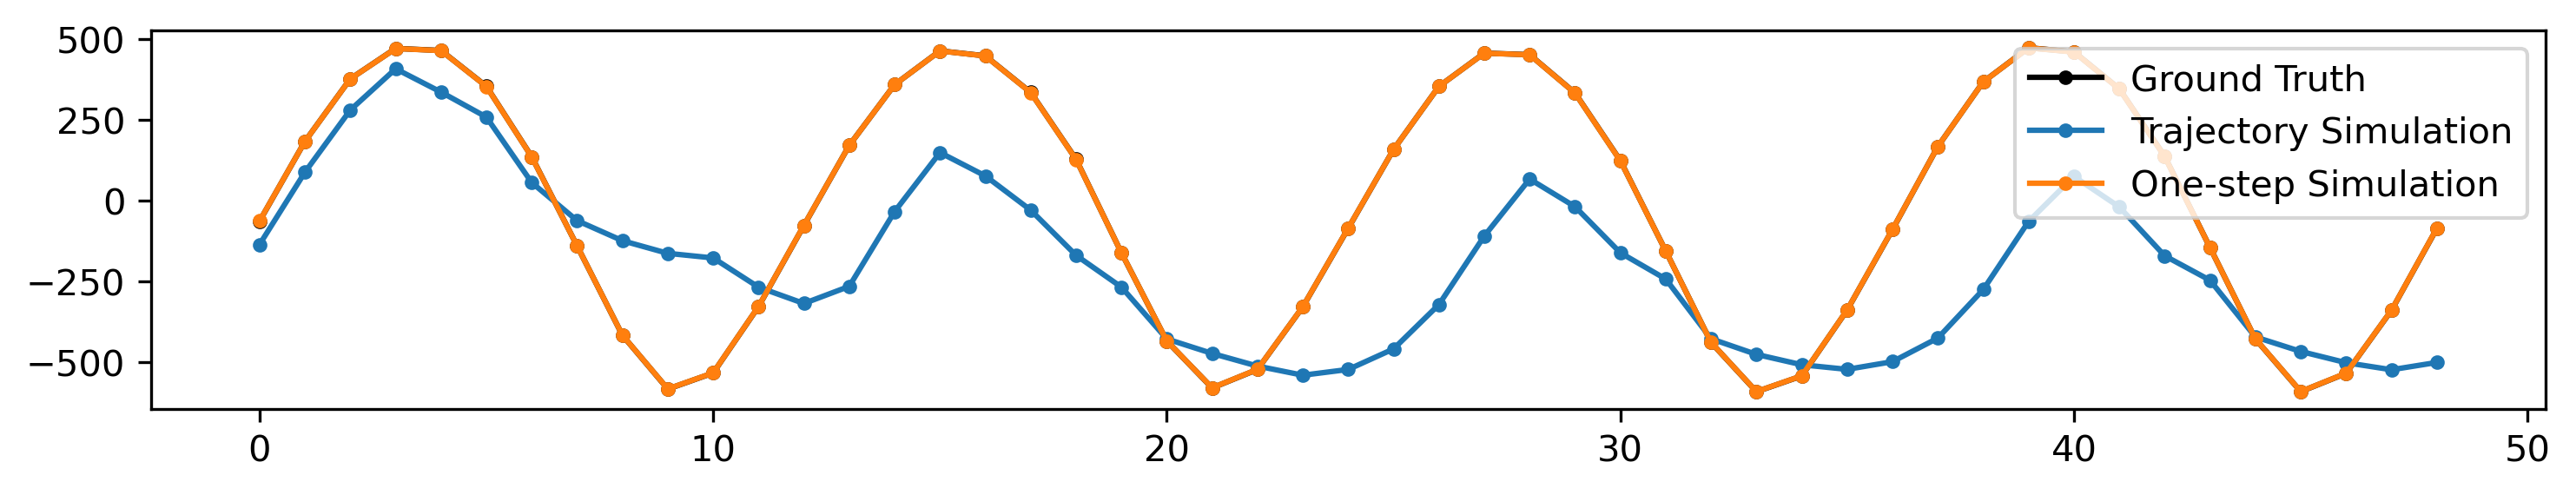

Iteration 2500, Loss(Ulam): 0.005106389056891203
Iteration 3000, Loss(Ulam): 0.0034702641423791647
Iteration 3500, Loss(Ulam): 0.0021918497513979673
Iteration 4000, Loss(Ulam): 0.0014532272471114993


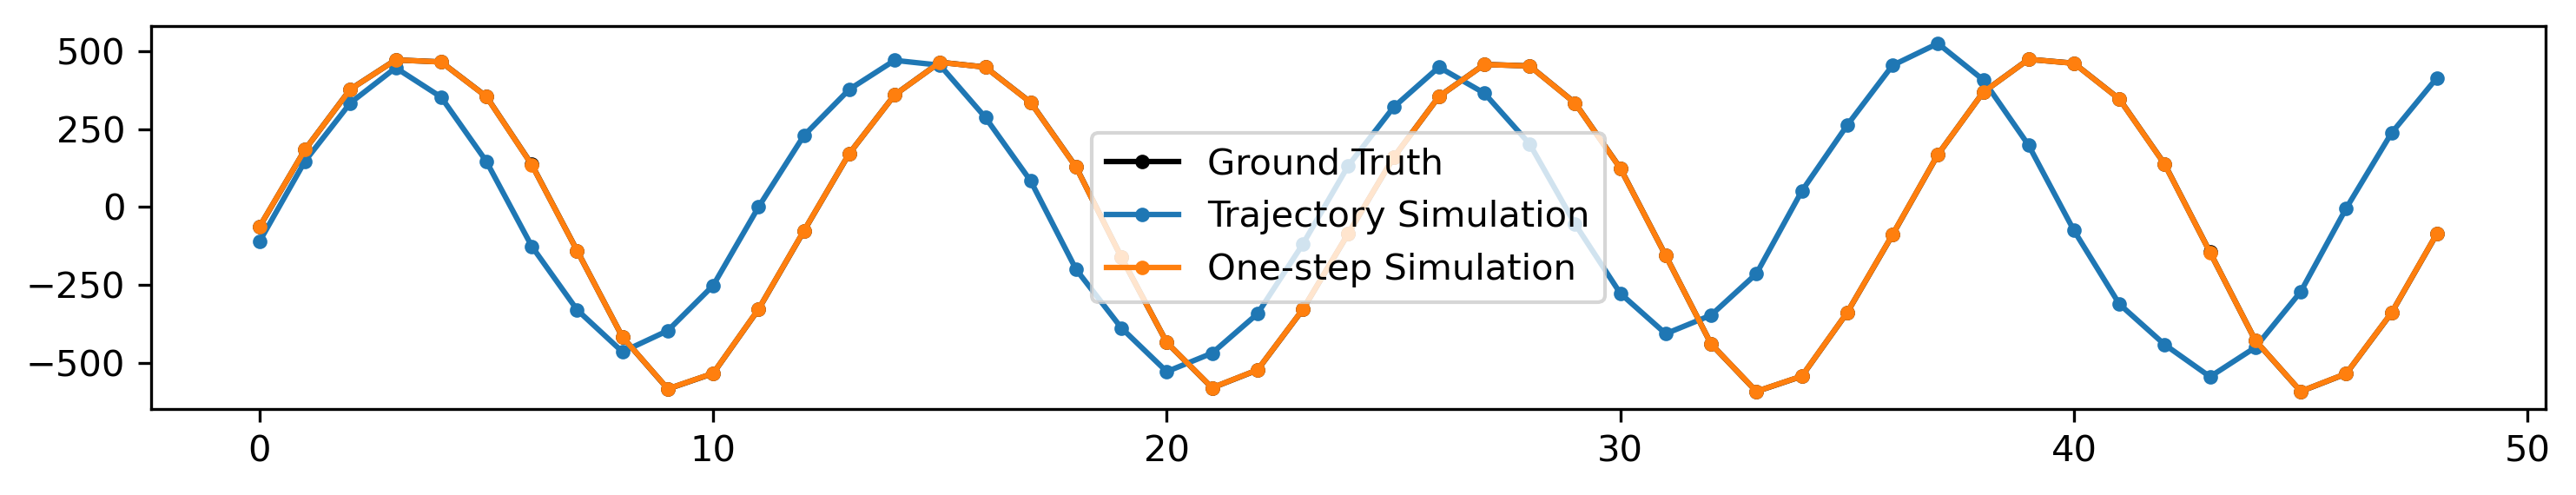

Iteration 4500, Loss(Ulam): 0.0011295279255136847
Iteration 5000, Loss(Ulam): 0.0008600617293268442
Iteration 5500, Loss(Ulam): 0.0006433416274376214
Iteration 6000, Loss(Ulam): 0.0004857063468080014


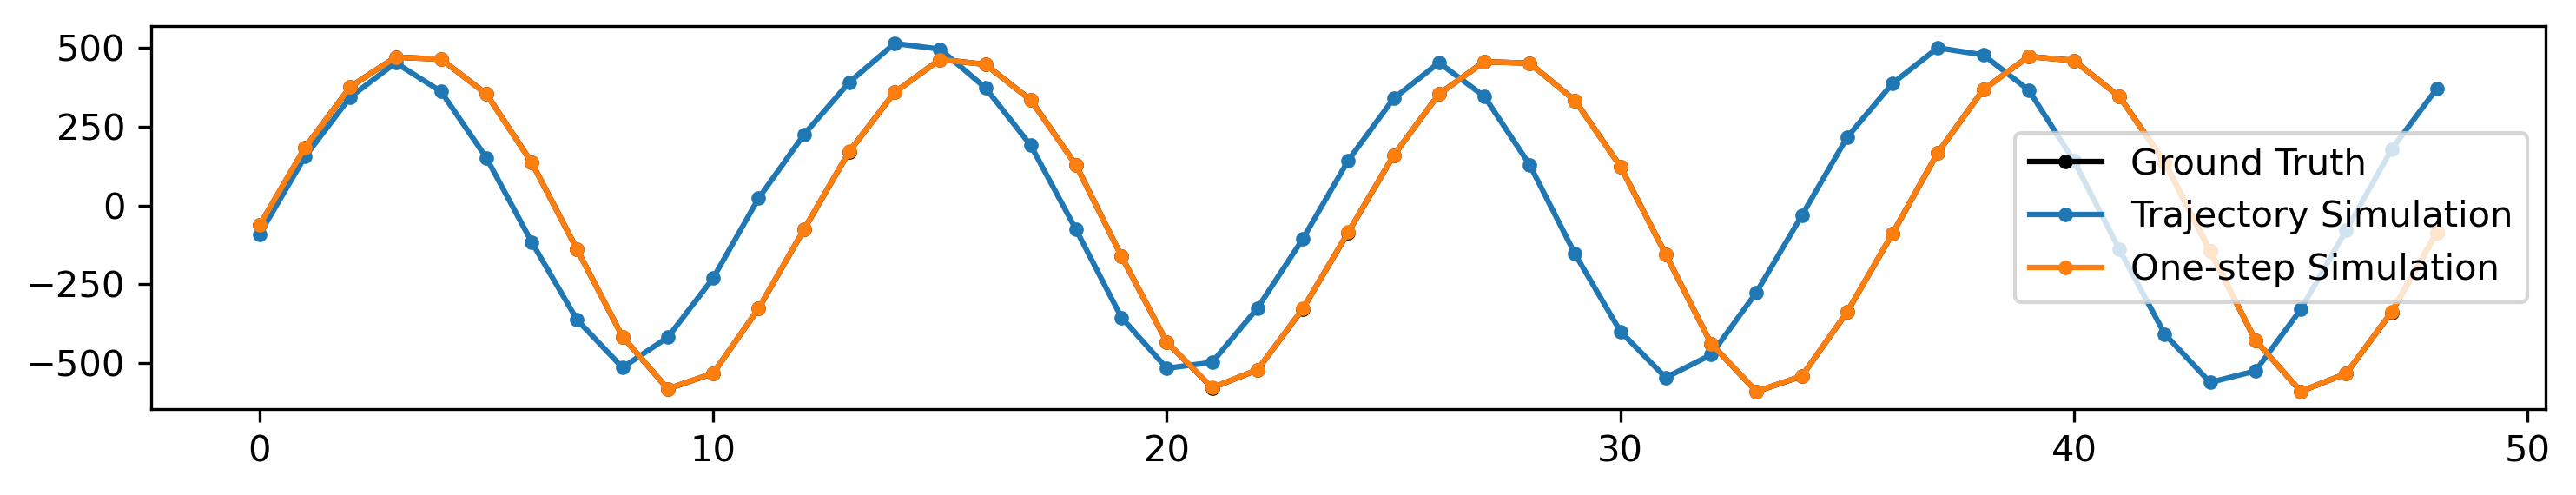

Early stopping at iteration 6000, Loss: 0.0004857063468080014


In [8]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer1.zero_grad()
    scheduler1.step()
    # Update for net1 (Ulam)
    net1_randpts = randpts
    V_field = net1(net1_randpts)
    net1_randpts = net1_randpts+dt* V_field
    U_net = Ulam(randpts, net1_randpts)
    L1 = W2Loss.apply(U_net)
    L1.backward()
    optimizer1.step()
    loss1.append(L1.item())  # Directly use .item() for scalar value

    if i % 500 == 0:
        print(f'Iteration {i}, Loss(Ulam): {L1.item()}')
        if i % 2000 == 0:
            x1 = randpts[sample_size-1].clone().detach().reshape(1, 4)
            vals1 = [x1.detach().numpy().flatten()]  # ensure all entries are numpy arrays

            for _ in range(300-1-sample_size):
                x1 = x1 + dt * net1(x1)
                vals1.append(x1.detach().numpy().flatten())  # now all elements are uniform shape/type
            predicted_coeffs = scaler.inverse_transform(vals1)  
            net1coeffs = coeffs[sample_size:]+dt*net1(torch.tensor(coeffs[sample_size:],dtype = torch.float)).detach().numpy()
            #ylabels = ["First POD coefficient", "Second POD coefficient", "Third POD coefficient"]

            fig, ax = plt.subplots(figsize=(10, 2), dpi=300)

            coeff_idx = 0
            ax.plot(coeffs[sample_size:-1, coeff_idx], ".-", label="Ground Truth", c="black")
            ax.plot(predicted_coeffs[1:, coeff_idx], ".-", label="Trajectory Simulation")
            ax.plot(net1coeffs[:-1, coeff_idx], ".-", label="One-step Simulation")
                #ax.plot(predicted_coeffs2[:, coeff_idx], ".-", label="Pointwise")
            #ax.set_ylabel(ylabels[i])
            ax.legend(loc="best")

            #axes[-1].set_xlabel("Month(t)")

            plt.tight_layout()
            plt.show()
        if L1.item() < 0.01 * initial_L1:
            print(f"Early stopping at iteration {i}, Loss: {L1.item()}")
            break


In [9]:
#pointwise
torch.manual_seed(100000)
net2 = nn.Sequential(
            nn.Linear(4, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 4))

optimizer2 = optim.Adam(net2.parameters(),lr = 1e-3)
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=2000, gamma=0.5)  
net2.train()
loss2 = []
net2_randpts = randpts.clone()  # safe copy, avoid modifying original tensor

V_field2 = net2(net2_randpts)
net2_randpts = net2_randpts + dt * V_field2  # out-of-place update
initial_L2 = torch.mean((net2_randpts - Trandpts) ** 2)


Iteration 0, Loss(Ulam): 0.4148343503475189


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


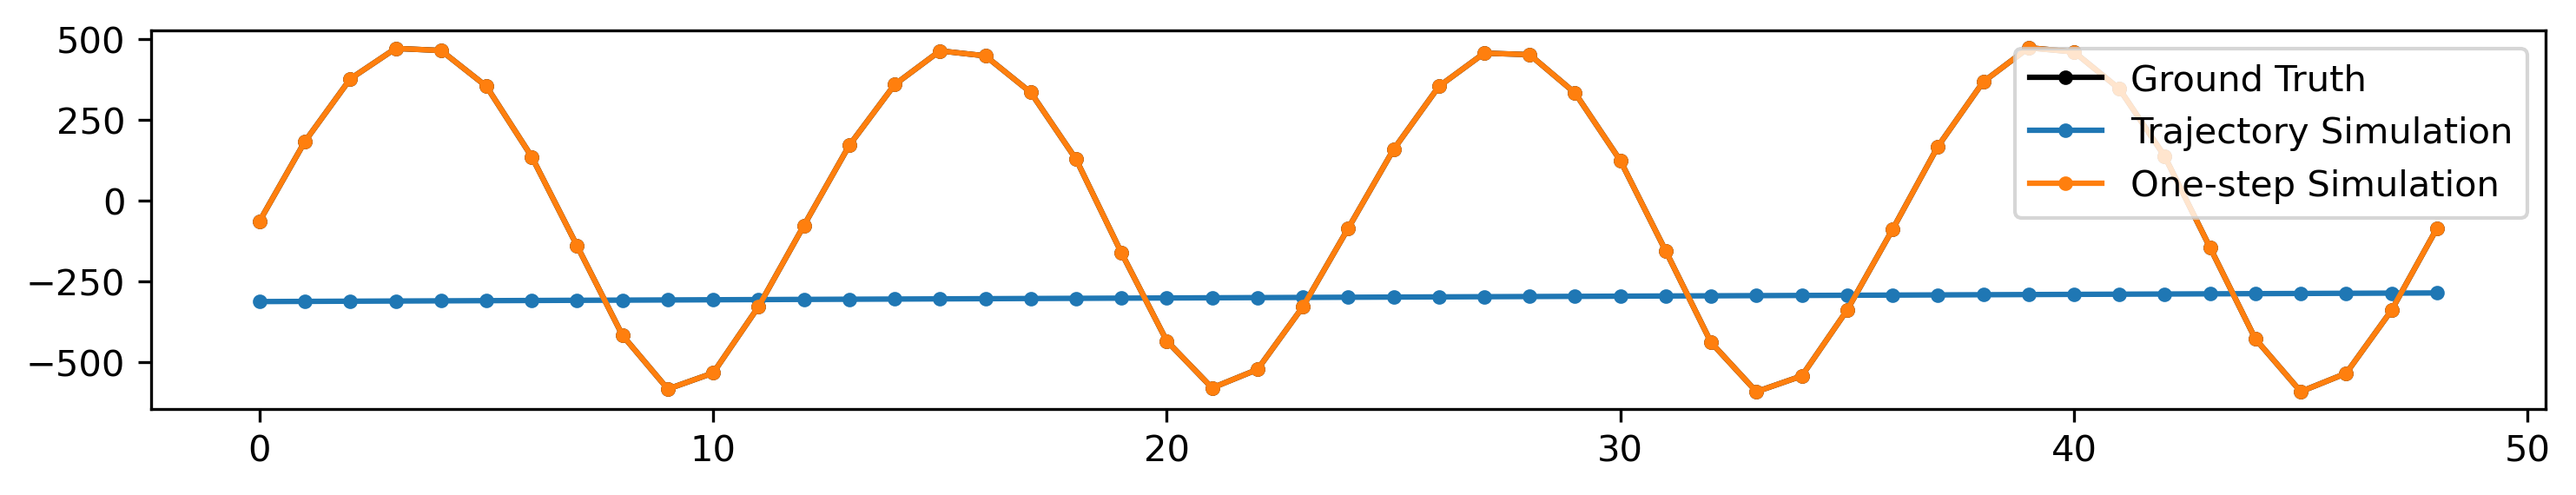

Iteration 500, Loss(Ulam): 0.1838250458240509
Iteration 1000, Loss(Ulam): 0.08595016598701477
Iteration 1500, Loss(Ulam): 0.04208514466881752
Iteration 2000, Loss(Ulam): 0.021958816796541214


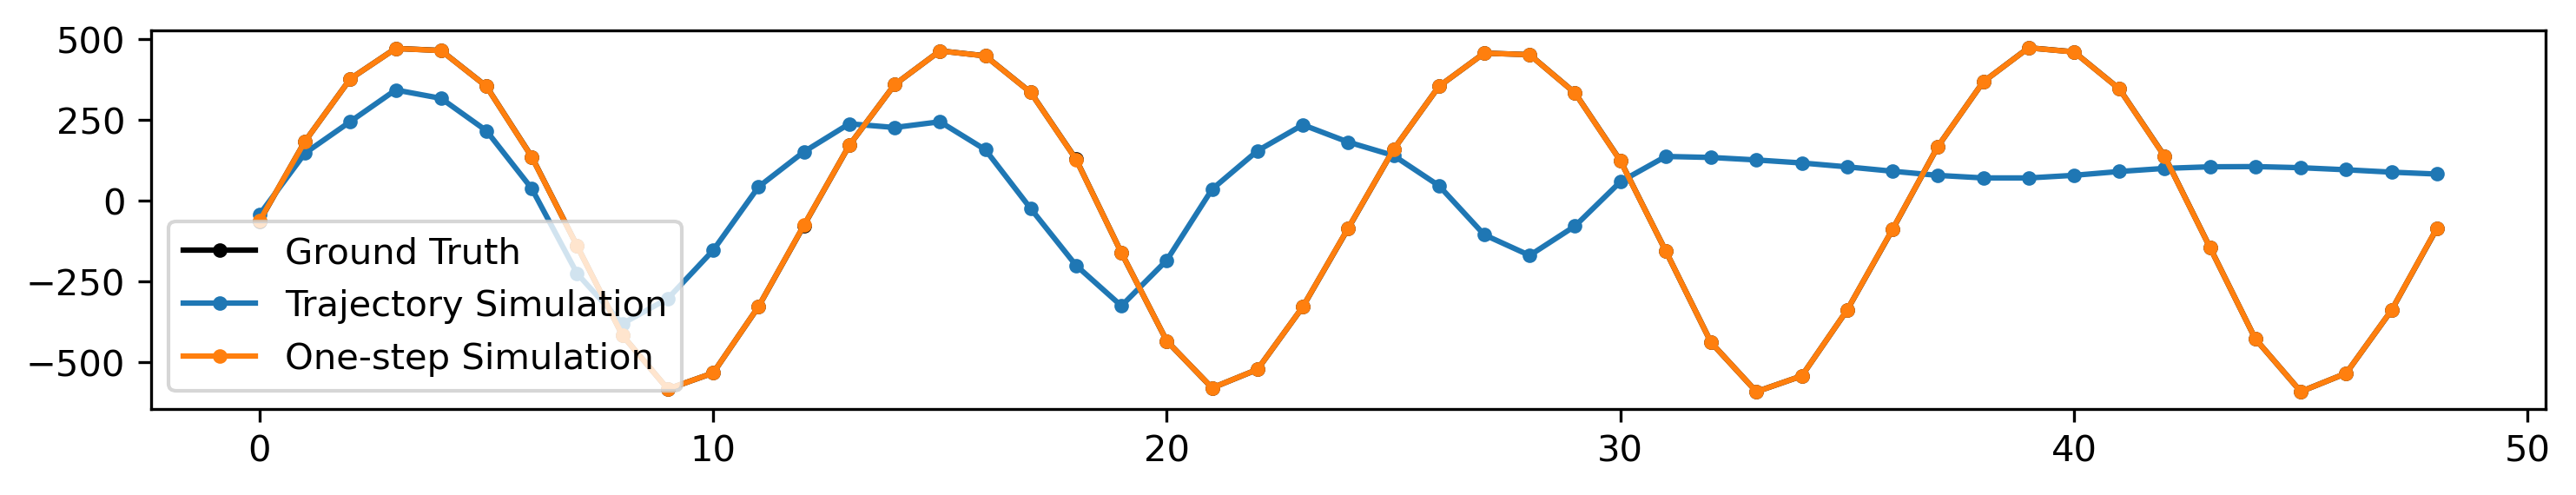

Iteration 2500, Loss(Ulam): 0.01561004389077425
Iteration 3000, Loss(Ulam): 0.010854546912014484
Iteration 3500, Loss(Ulam): 0.007436866872012615
Iteration 4000, Loss(Ulam): 0.004634845070540905


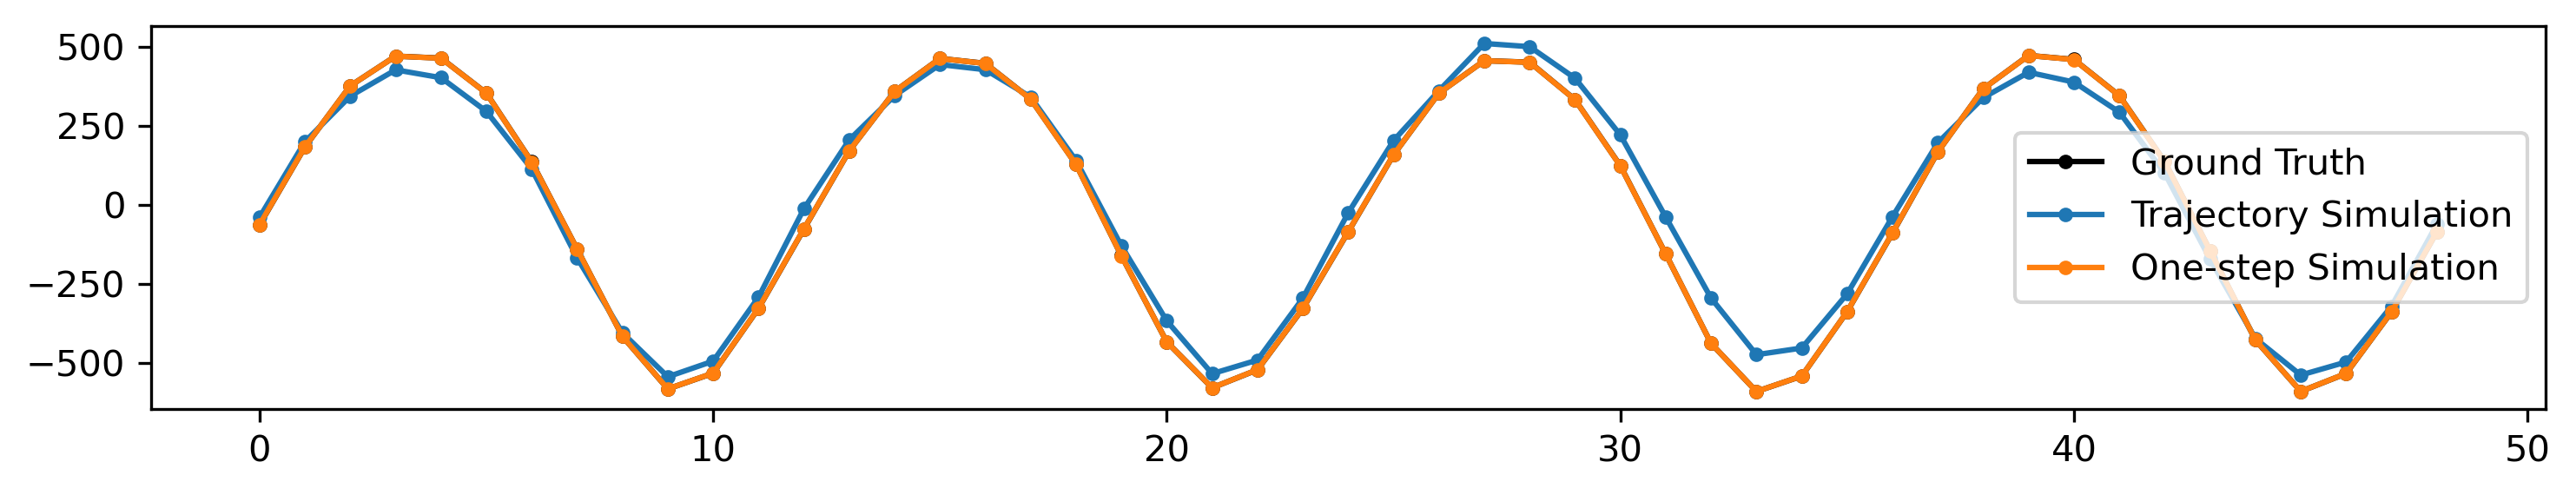

Iteration 4500, Loss(Ulam): 0.003622817574068904
Early stopping at iteration 4500, Loss: 0.003622817574068904


In [10]:
for i in range(N_iters):
    # Zero gradients for each optimizer
    optimizer2.zero_grad()
    scheduler2.step()
    net2_randpts = randpts
    V_field2 = net2(net2_randpts)
    net2_randpts = net2_randpts+dt* V_field2
    L2 = torch.mean((net2_randpts - Trandpts) ** 2)
    L2.backward()
    optimizer2.step()
    loss2.append(L2.item())

    if i % 500 == 0:
        print(f'Iteration {i}, Loss(Ulam): {L2.item()}')
        if i % 2000 == 0:
            x1 = randpts[sample_size-1].clone().detach().reshape(1, 4)
            vals2 = [x1.detach().numpy().flatten()]  # ensure all entries are numpy arrays

            for _ in range(300-1-sample_size):
                x1 = x1 + dt * net2(x1)
                vals2.append(x1.detach().numpy().flatten())  # now all elements are uniform shape/type
            predicted_coeffs2 = scaler.inverse_transform(vals2)  
            net2coeffs = coeffs[sample_size:]+dt*net2(torch.tensor(coeffs[sample_size:],dtype = torch.float)).detach().numpy()
            #ylabels = ["First POD coefficient", "Second POD coefficient", "Third POD coefficient"]

            fig, ax = plt.subplots(figsize=(10, 2), dpi=300)

            coeff_idx = 0
            ax.plot(coeffs[sample_size:-1, coeff_idx], ".-", label="Ground Truth", c="black")
            ax.plot(predicted_coeffs2[1:, coeff_idx], ".-", label="Trajectory Simulation")
            ax.plot(net2coeffs[:-1, coeff_idx], ".-", label="One-step Simulation")
                #ax.plot(predicted_coeffs2[:, coeff_idx], ".-", label="Pointwise")
            #ax.set_ylabel(ylabels[i])
            ax.legend(loc="best")

            #axes[-1].set_xlabel("Month(t)")

            plt.tight_layout()
            plt.show()
        if L2.item() < 0.01 * initial_L2:
            print(f"Early stopping at iteration {i}, Loss: {L2.item()}")
            break

In [11]:
x1 = randpts[sample_size-1].clone().detach().reshape(1, 4)
vals1 = [x1.detach().numpy().flatten()]  # ensure all entries are numpy arrays

for _ in range(300-1-sample_size):
    x1 = x1 + dt * net1(x1)
    vals1.append(x1.detach().numpy().flatten())  # now all elements are uniform shape/type

predicted_coeffs = scaler.inverse_transform(vals1)  

In [12]:
x2 = randpts[sample_size-1].clone().detach().reshape(1, 4)
vals2 = [x2.detach().numpy().flatten()]  # ensure all entries are numpy arrays

for _ in range(300-1-sample_size):
    x2 = x2 + dt * net2(x2)
    vals2.append(x2.detach().numpy().flatten())  # now all elements are uniform shape/type

predicted_coeffs2 = scaler.inverse_transform(vals2)  

In [13]:
net1coeffs = coeffs[sample_size:]+dt*scaler.inverse_transform(net1(torch.tensor(coeffs[sample_size:],dtype = torch.float)).detach().numpy())
net2coeffs = coeffs[sample_size:]+dt*scaler.inverse_transform(net2(torch.tensor(coeffs[sample_size:],dtype = torch.float)).detach().numpy())


In [14]:
a, b = np.ones((300-sample_size,)) / (300-sample_size), np.ones((300-sample_size,)) / (300-sample_size)
M1, M2 = ot.dist(coeffs[sample_size-1:-1], predicted_coeffs),ot.dist(coeffs[sample_size-1:-1], predicted_coeffs2)##
_,G01 = ot.emd(a, b, M1,log = 'true')
_,G02 = ot.emd(a, b, M2,log = 'true')
    #W2 ERRORS
cost1W,cost2W = G01['cost']**(1/2),G02['cost']**(1/2)

cost1L = np.mean((net1coeffs-coeffs[sample_size:])**2)**(1/2)
cost2L = np.mean((net2coeffs-coeffs[sample_size:])**2)**(1/2)


In [15]:
cost1W, cost2W, cost1L, cost2L

(66.67524042225892, 95.8308133744116, 69.32812676076175, 72.03096868166324)

In [31]:
#costs1W, costs2W, costs1L, costs2L = [],[],[],[]
costs1W.append(cost1W)
costs2W.append(cost2W)
costs1L.append(cost1L)
costs2L.append(cost2L)

In [142]:
# plt.scatter(coeffs[sample_size-1:-1][:,0],coeffs[sample_size-1:-1][:,1])
# plt.scatter(predicted_coeffs[:,0],predicted_coeffs[:,1]) 
# plt.show()

In [143]:
# net1coeffs = coeffs[sample_size:]+dt*net1(torch.tensor(coeffs[sample_size:],dtype = torch.float)).detach().numpy()
# net2coeffs = coeffs[sample_size:]+dt*net2(torch.tensor(coeffs[sample_size:],dtype = torch.float)).detach().numpy()
# cost1L = np.mean((net1coeffs-coeffs[sample_size-1:-1])**2)**(1/2), 
# cost2L = np.mean((net2coeffs-coeffs[sample_size-1:-1])**2)**(1/2)

In [153]:
np.mean(costs1L),np.std(costs1L)

(64.50274063124162, 5.12790417754493)

In [146]:
np.mean(costs2L),np.std(costs2L)

(70.05538061136066, 2.737996697042969)

In [147]:
np.mean(costs1W),np.std(costs1W)

(72.94168230285847, 9.074792787671946)

In [148]:
np.mean(costs2W),np.std(costs2W)

(92.27709853753998, 17.968085658925588)

In [16]:
reconstructed1 = Reconstruct_POD(modes,predicted_coeffs,mean) #this is how you reconstruct the full state based on coeffs 
remapped1 = Remap(reconstructed1)
reconstructed2 = Reconstruct_POD(modes,predicted_coeffs2,mean)
remapped2 = Remap(reconstructed2)

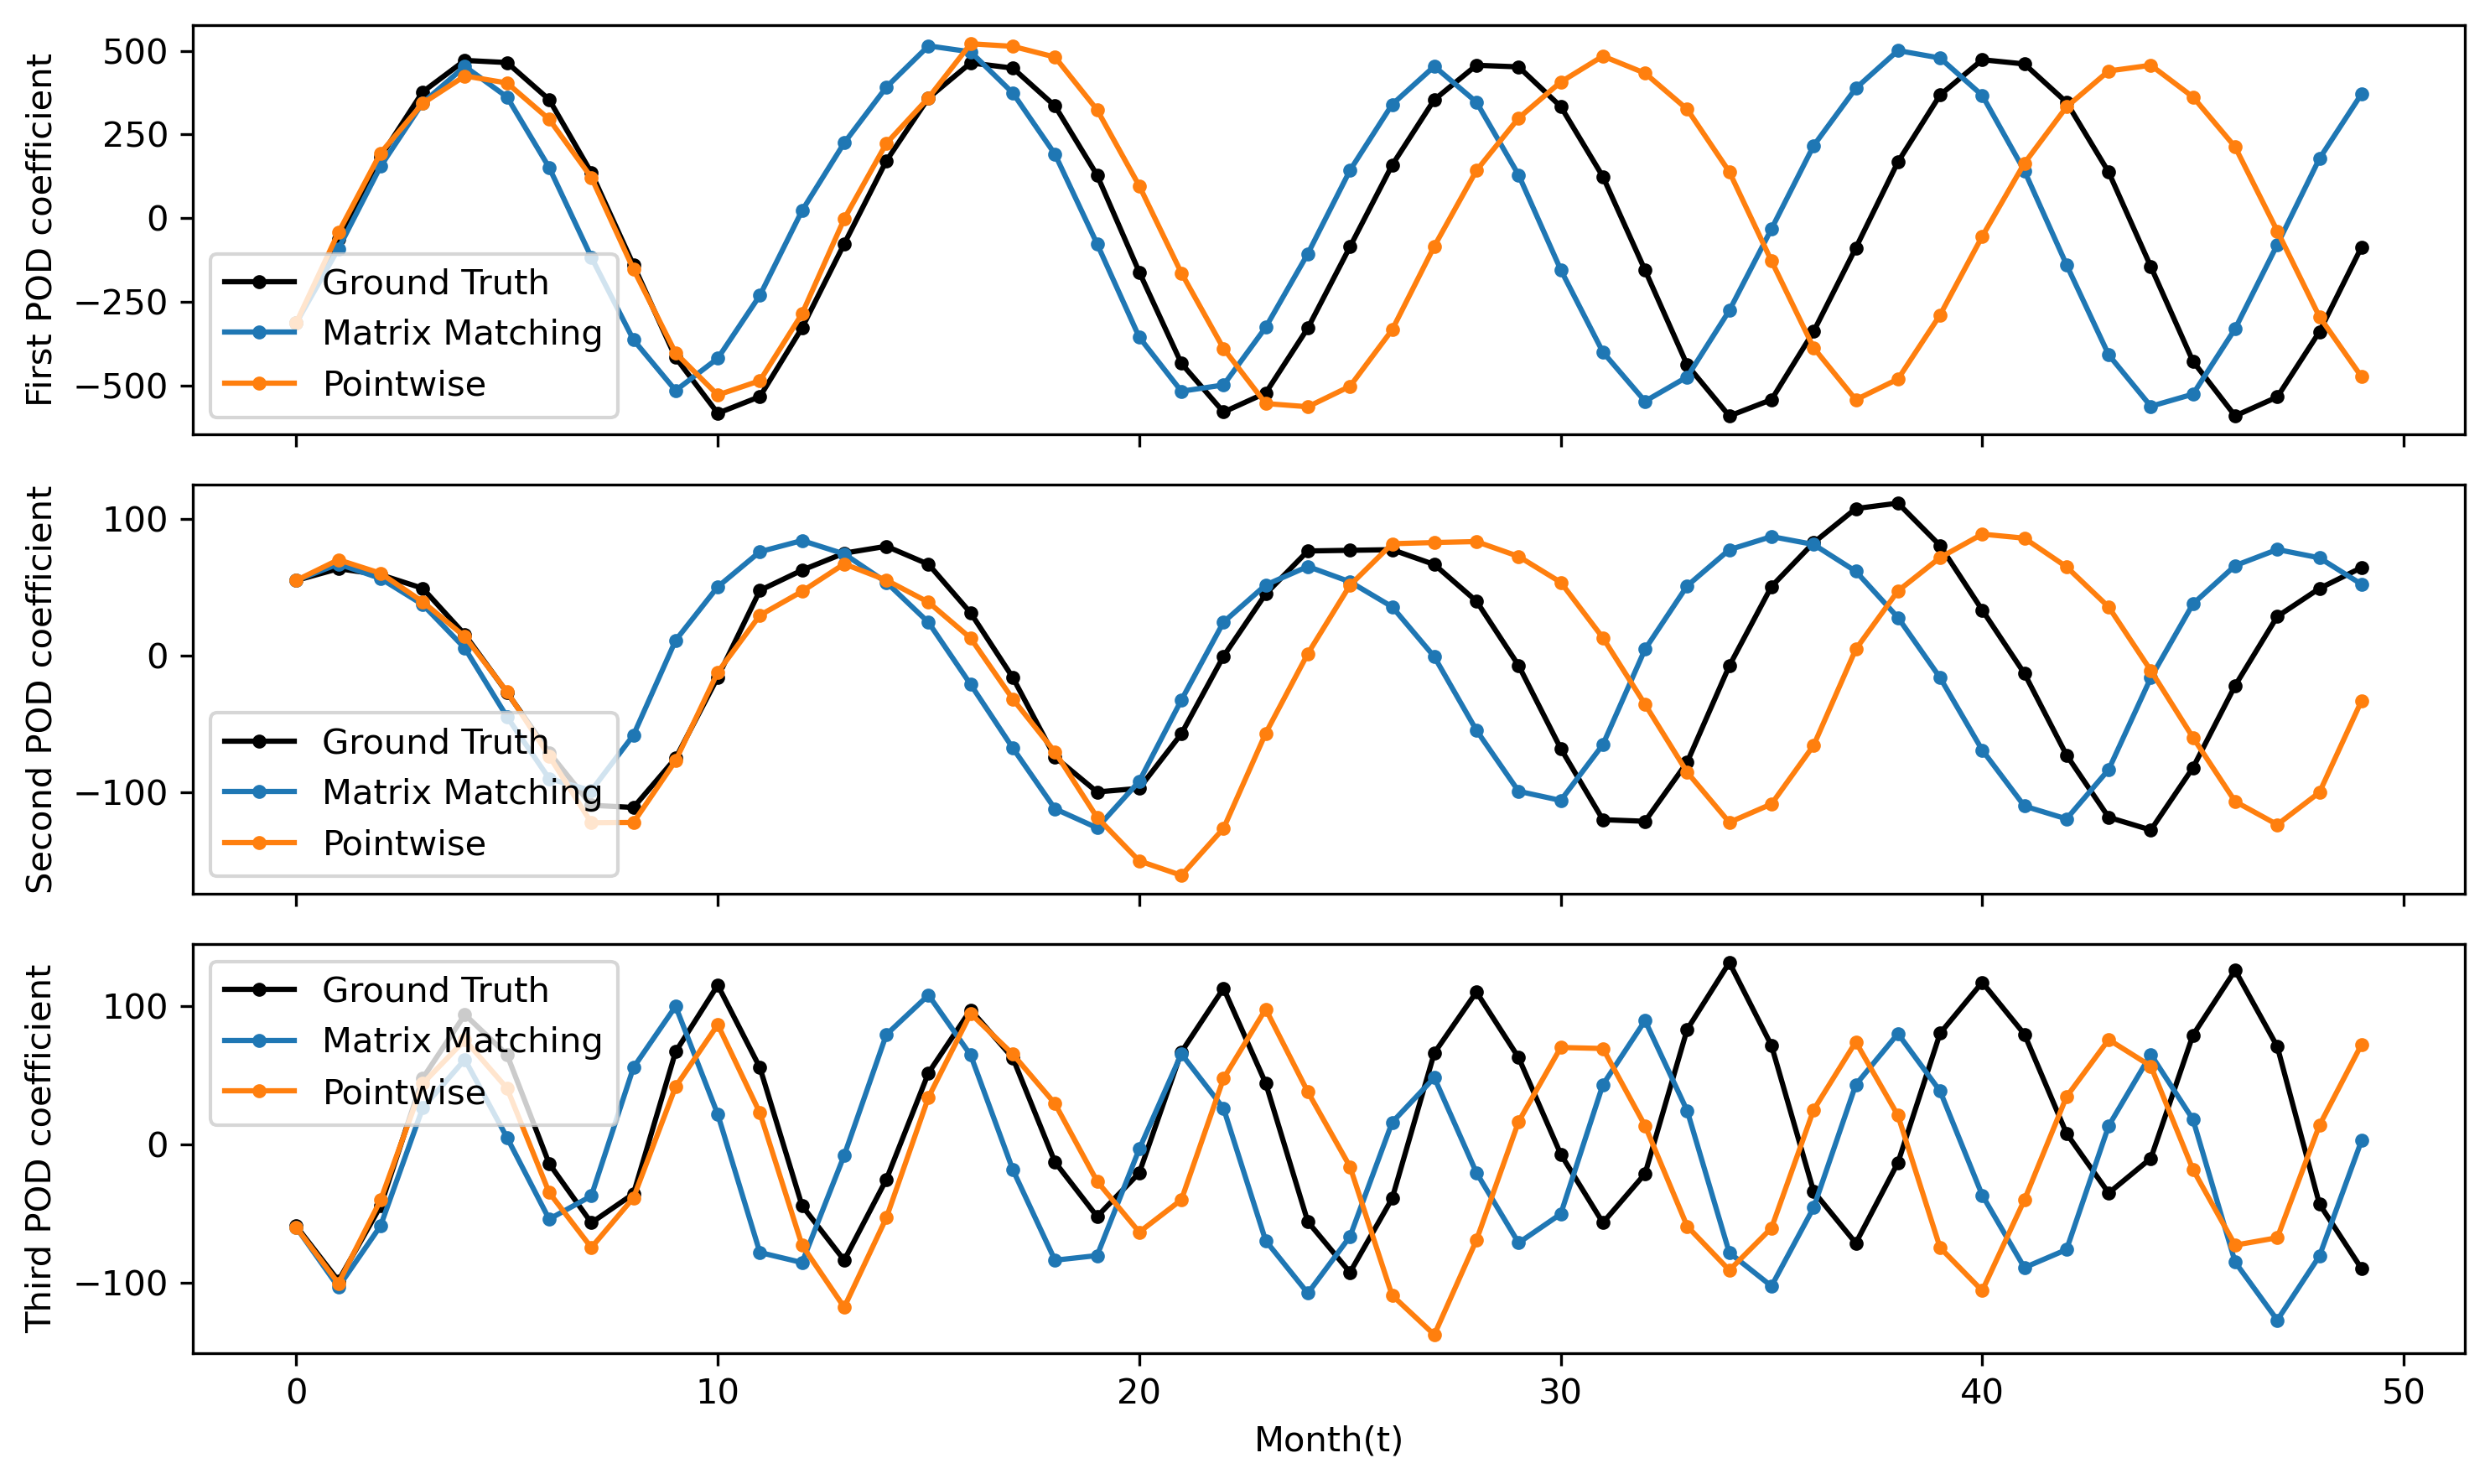

In [17]:

ylabels = ["First POD coefficient", "Second POD coefficient", "Third POD coefficient"]

fig, axes = plt.subplots(3, 1, figsize=(10, 6), dpi=300, sharex=True)

for i, ax in enumerate(axes):
    coeff_idx = i
    ax.plot(coeffs[sample_size-1:-1, coeff_idx], ".-", label="Ground Truth", c="black")
    ax.plot(predicted_coeffs[:, coeff_idx], ".-", label="Matrix Matching")
    ax.plot(predicted_coeffs2[:, coeff_idx], ".-", label="Pointwise")
    ax.set_ylabel(ylabels[i])
    ax.legend(loc="best")

axes[-1].set_xlabel("Month(t)")

plt.tight_layout()
plt.show()


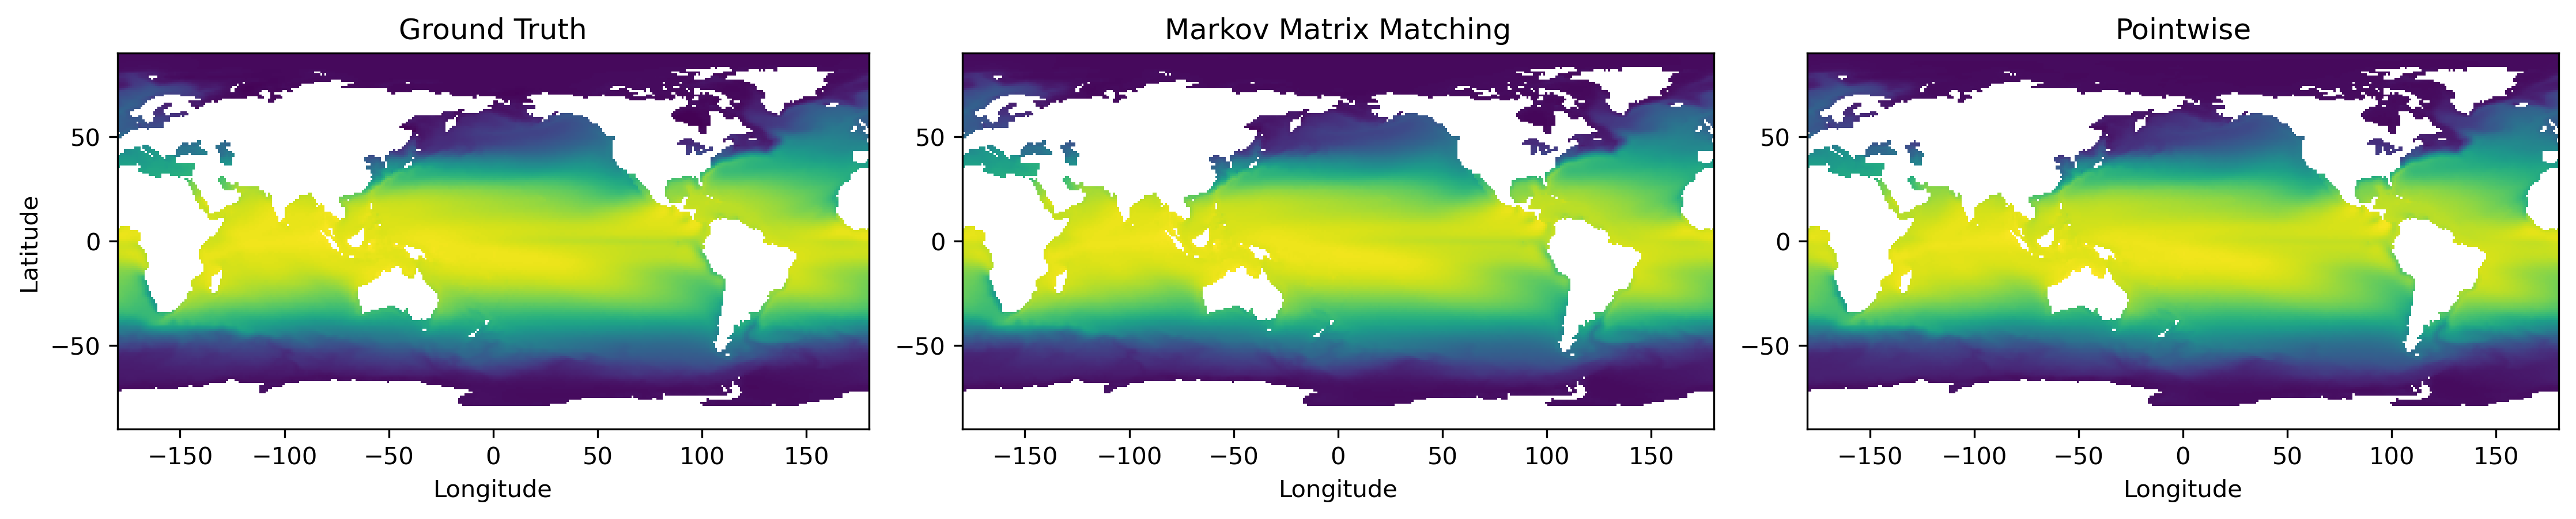

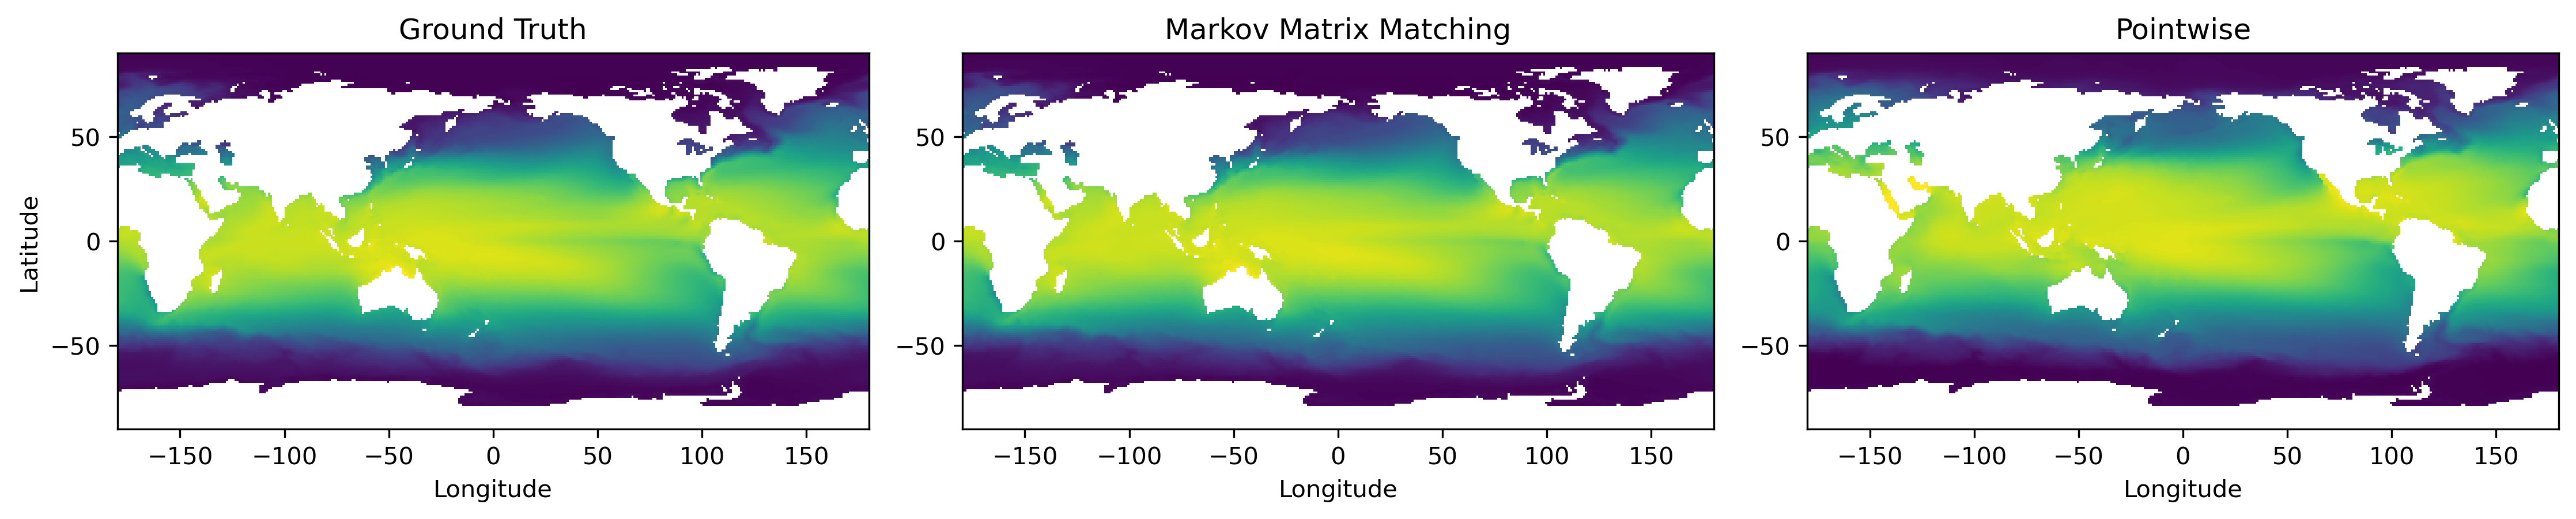

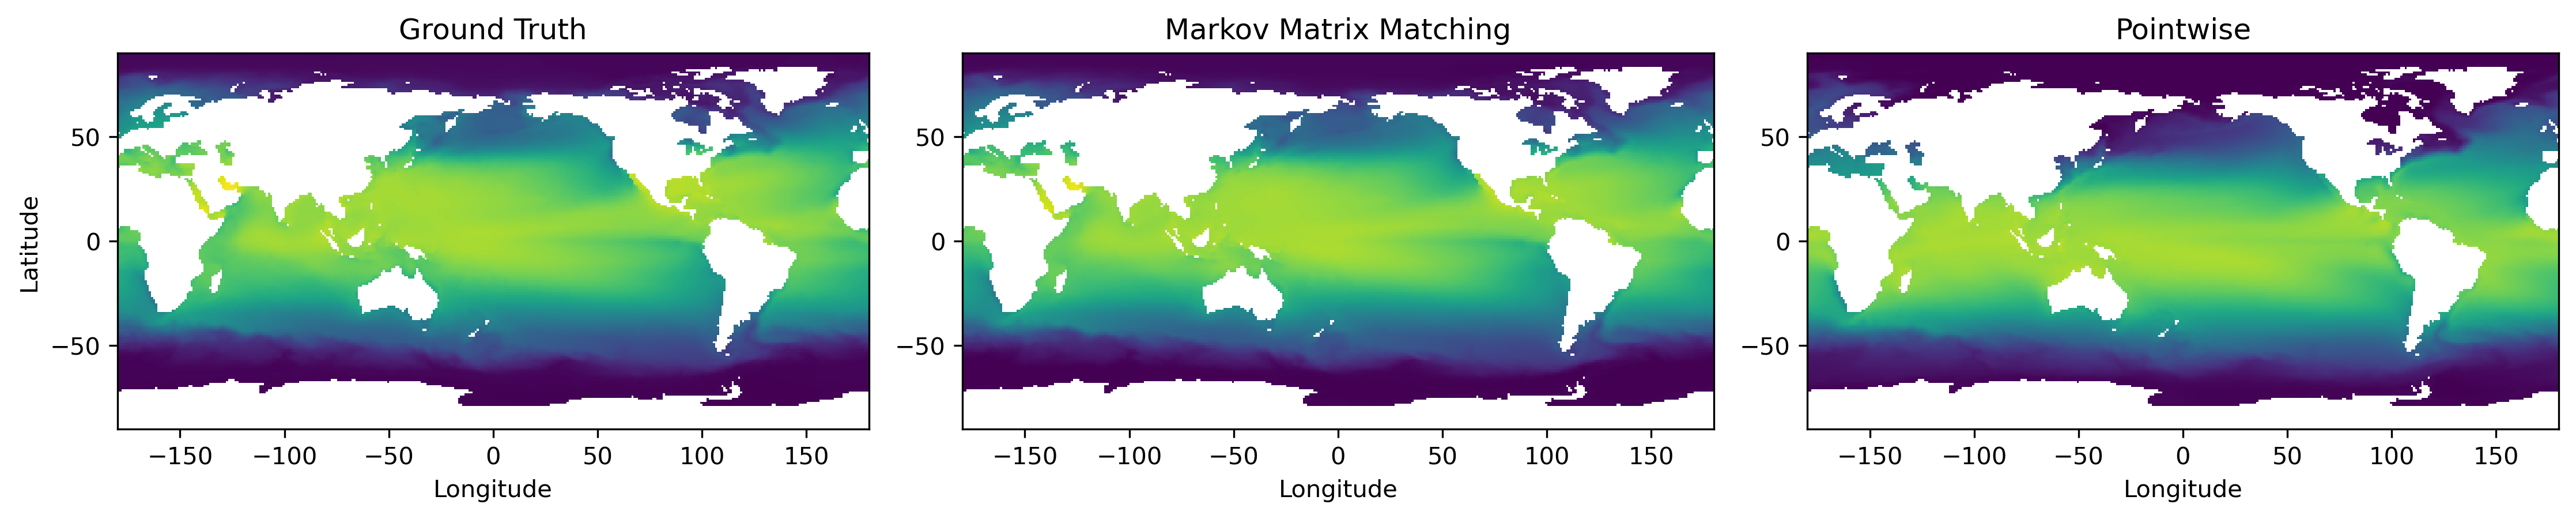

In [18]:
lon_min, lon_max = -180, 180
lat_min, lat_max = -90, 90

for i in [5,25,45]:  # or a range
    plt.figure(figsize=(15, 5), dpi=300)
    plt.clf()

    vmin = remapped[sample_size+i].min()
    vmax = remapped[sample_size+i].max()

    extent = [lon_min, lon_max, lat_min, lat_max]

    plt.subplot(1, 3, 1)
    plt.title('Ground Truth')
    plt.imshow(remapped[sample_size+i], origin='lower', extent=extent, vmin=vmin, vmax=vmax)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.subplot(1, 3, 2)
    plt.title('Markov Matrix Matching')
    plt.imshow(remapped1[i], origin='lower', extent=extent, vmin=vmin, vmax=vmax)
    plt.xlabel("Longitude")

    plt.subplot(1, 3, 3)
    plt.title('Pointwise')
    plt.imshow(remapped2[i], origin='lower', extent=extent, vmin=vmin, vmax=vmax)
    plt.xlabel("Longitude")

    plt.tight_layout()
    plt.show()


In [19]:

# Create a temporary directory to store frames
os.makedirs("gif_frames", exist_ok=True)
frames = []

# # Set consistent color scale (or adjust as needed)
# vmin = remapped[150:300].min()
# vmax = remapped[150:300].max()

for i in range(299-sample_size):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4), dpi=300)
    extent = [lon_min, lon_max, lat_min, lat_max]
    axs[0].imshow(remapped[sample_size + i], origin='lower',  extent=extent,vmin=vmin, vmax=vmax)
    axs[0].set_title('Ground Truth')
    axs[0].set_xlabel("Longtitude")
    axs[0].set_ylabel("Latitude")

    axs[1].imshow(remapped1[i], origin='lower',  extent=extent,vmin=vmin, vmax=vmax)
    axs[1].set_title('Markov Matrix Matching')
    axs[1].set_xlabel("Longtitude")
    axs[1].set_ylabel("Latitude")

    axs[2].imshow(remapped2[i], origin='lower', extent=extent, vmin=vmin, vmax=vmax)
    axs[2].set_title('Pointwise')
    axs[2].set_xlabel("Longtitude")
    axs[2].set_ylabel("Latitude")

    # Save to temporary file
    frame_path = f"gif_frames/frame_{i:03d}.png"
    plt.tight_layout()
    plt.savefig(frame_path)
    plt.close()
    frames.append(imageio.imread(frame_path))  # Read image into memory

# Save as GIF
imageio.mimsave("comparison.gif", frames, duration=0.1)  # duration in seconds per frame


/tmp/ipykernel_1925811/1715357928.py:32: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(frame_path))  # Read image into memory


In [20]:
HTML('<img src="comparison.gif" />')

/tmp/ipykernel_1925811/2427440048.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave room on the right for colorbar


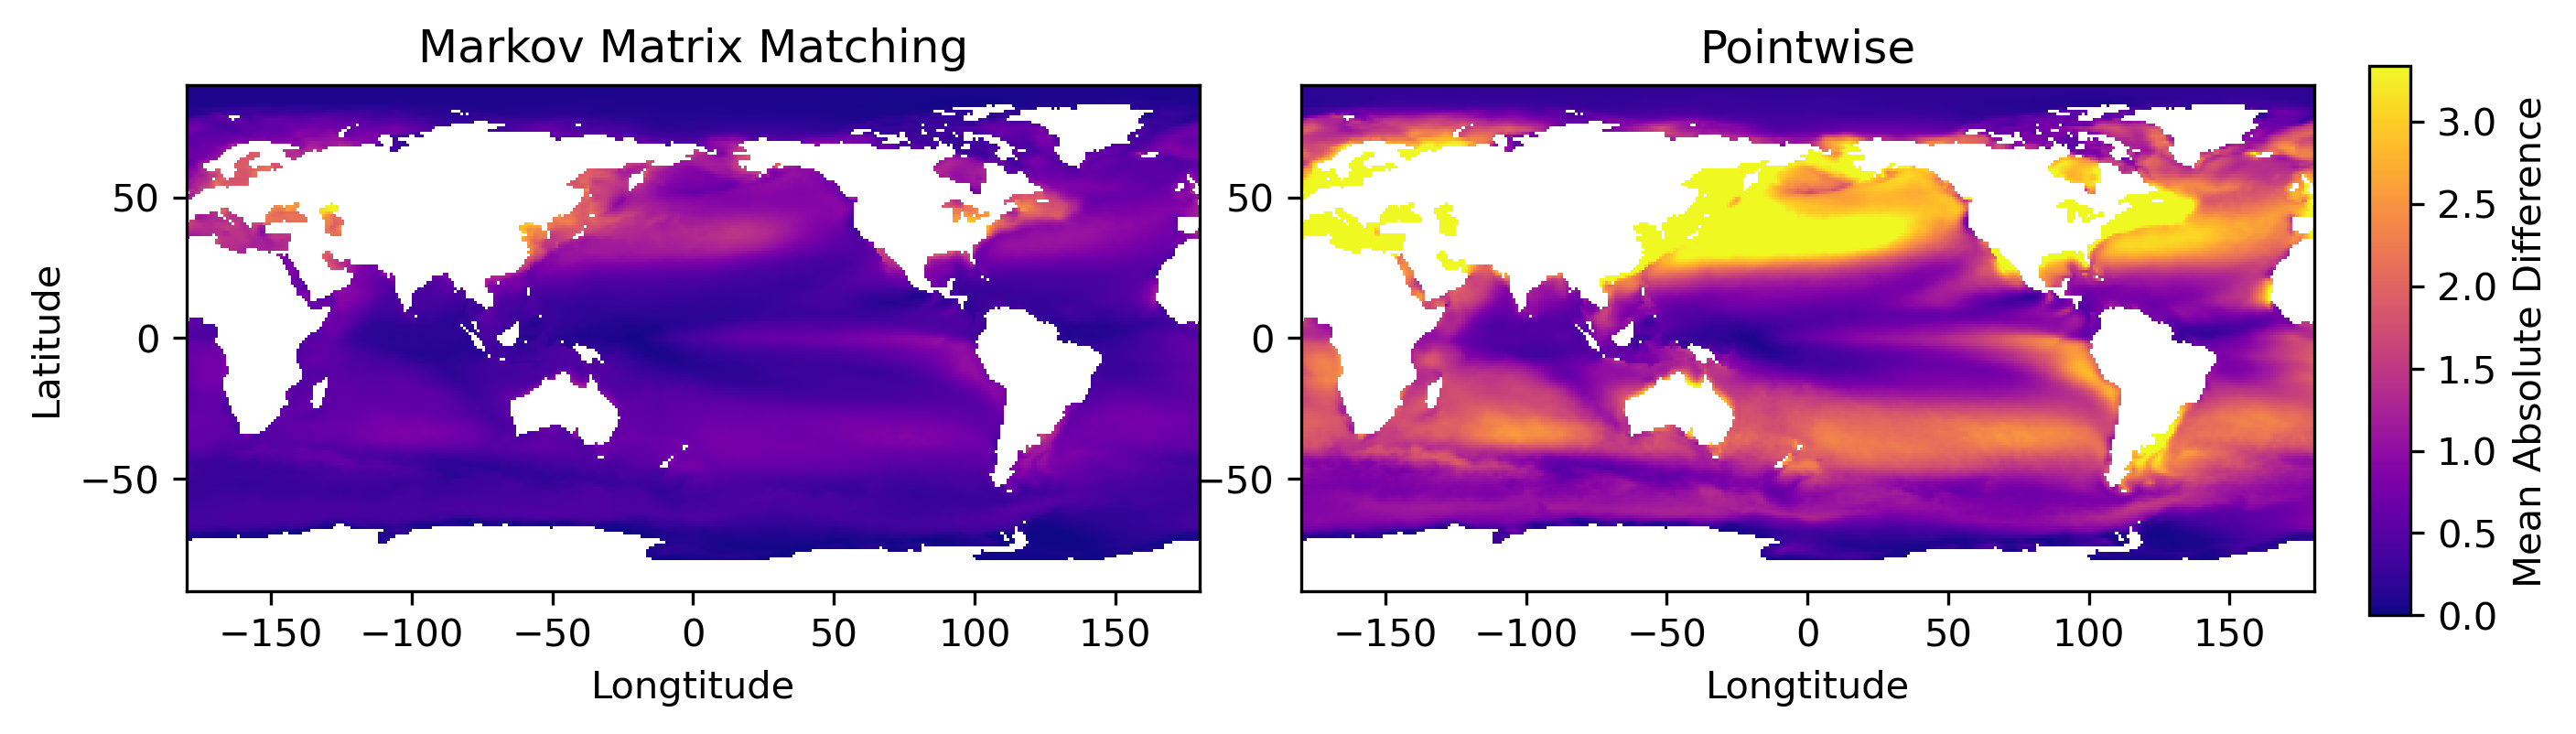

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300,
                         gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.1})

# First image
im1 = axes[0].imshow(np.mean(abs(remapped[sample_size:] - remapped1), axis=0),
                     origin='lower',  extent=extent,vmin=0, vmax=np.max(np.mean(abs(remapped[sample_size:] - remapped1), axis=0)),cmap='plasma')
axes[0].set_title("Markov Matrix Matching")#XXX Matching
axes[0].set_xlabel("Longtitude")
axes[0].set_ylabel("Latitude")

# Second image
im2 = axes[1].imshow(np.mean(abs(remapped[sample_size:] - remapped2), axis=0),
                     origin='lower',  extent=extent,vmin=0, vmax=np.max(np.mean(abs(remapped[sample_size:] - remapped1), axis=0)),cmap='plasma')
axes[1].set_title("Pointwise")
axes[1].set_xlabel("Longtitude")
#axes[1].set_ylabel("Latitude")

# Add an axis for the colorbar beside the last plot
cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(im2, cax=cbar_ax)
cbar.set_label("Mean Absolute Difference")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave room on the right for colorbar
plt.show()


In [22]:
os.makedirs("gif_frames", exist_ok=True)
frames = []
vmax = np.max(abs(remapped[sample_size:] - remapped2))
for i in range(299-sample_size):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300,
                         gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.1})
    
# First image
    im1 = axes[0].imshow(abs(remapped[sample_size:][i] - remapped1[i]),
                     origin='lower',  extent=extent,vmin=0, vmax=vmax,cmap='plasma')
    axes[0].set_title("Markov Matrix Matching")#XXX Matching
    axes[0].set_xlabel("Longtitude")
    axes[0].set_ylabel("Latitude")

# Second image
    im2 = axes[1].imshow(abs(remapped[sample_size:][i] - remapped2[i]),
                     origin='lower',  extent=extent,vmin=0, vmax=vmax,cmap='plasma')
    axes[1].set_title("Pointwise")
    axes[1].set_xlabel("Longtitude")
#axes[1].set_ylabel("Latitude")

# Add an axis for the colorbar beside the last plot
    cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])  # [left, bottom, width, height]
    cbar = fig.colorbar(im2, cax=cbar_ax)
    cbar.set_label("Absolute Difference")

    plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave room on the right for colorbar
    # Save to temporary file
    frame_path = f"gif_frames/frame_{i:03d}.png"
    plt.savefig(frame_path)
    plt.close()
    frames.append(imageio.imread(frame_path))  # Read image into memory

# Save as GIF
imageio.mimsave("Absolute Difference.gif", frames, duration=0.1) 

/tmp/ipykernel_1925811/702600463.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave room on the right for colorbar
/tmp/ipykernel_1925811/702600463.py:32: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(frame_path))  # Read image into memory


In [23]:
HTML('<img src="Absolute Difference.gif" />')